In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
# import shap
import os
for dirname,  _, filenames in os.walk('assets'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

assets\sample_submission.csv
assets\test.csv
assets\train.csv


In [2]:
train_df = pd.read_csv('assets/train.csv')
test_df = pd.read_csv('assets/test.csv')
X = train_df.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train_df['diagnosed_diabetes']

X_test = test_df.drop('id', axis=1)

In [3]:
numeric_feature = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_feature = X.select_dtypes(include=['object']).columns.tolist()
print(f"numeric_feature: {numeric_feature}")
print(f"categorical_feature: {categorical_feature}")

numeric_feature: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']
categorical_feature: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']


In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12,8]

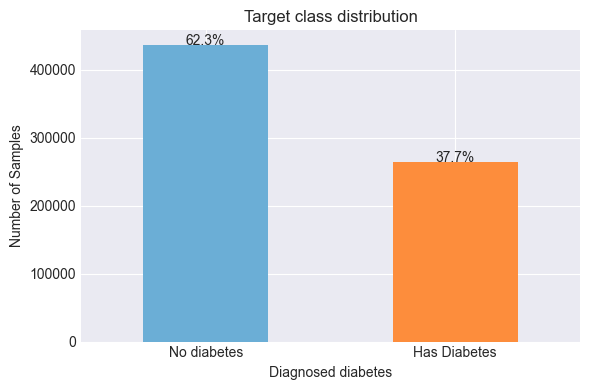

In [5]:
counts = train_df['diagnosed_diabetes'].value_counts(normalize=True)*100
plt.figure(figsize=(6,4))
ax = train_df['diagnosed_diabetes'].value_counts().plot(
    kind='bar',
    color=['#6baed6', '#fd8d3c']
)

plt.title('Target class distribution')
plt.xlabel('Diagnosed diabetes')
plt.ylabel('Number of Samples')
plt.xticks([0,1], ['No diabetes', 'Has Diabetes'], rotation=0)

for i, v in enumerate(train_df['diagnosed_diabetes'].value_counts()):
    ax.text(i, v + 500, f"{counts.iloc[i]:.1f}%", ha='center')

plt.tight_layout()
plt.show()

In [6]:
train_encoded = train_df.copy()
for col in categorical_feature:
    train_encoded[col] = pd.factorize(train_df[col])[0]

all_feature = numeric_feature + categorical_feature + ['diagnosed_diabetes']
corr_matrix = train_encoded[all_feature].corr()

Top 10 features by correlation with the target variable:
diagnosed_diabetes                    1.000000
family_history_diabetes               0.211064
physical_activity_minutes_per_week    0.169789
age                                   0.161162
systolic_bp                           0.107132
bmi                                   0.105580
ldl_cholesterol                       0.102771
triglycerides                         0.090635
cholesterol_total                     0.088112
waist_to_hip_ratio                    0.081050
hdl_cholesterol                       0.053231
Name: diagnosed_diabetes, dtype: float64


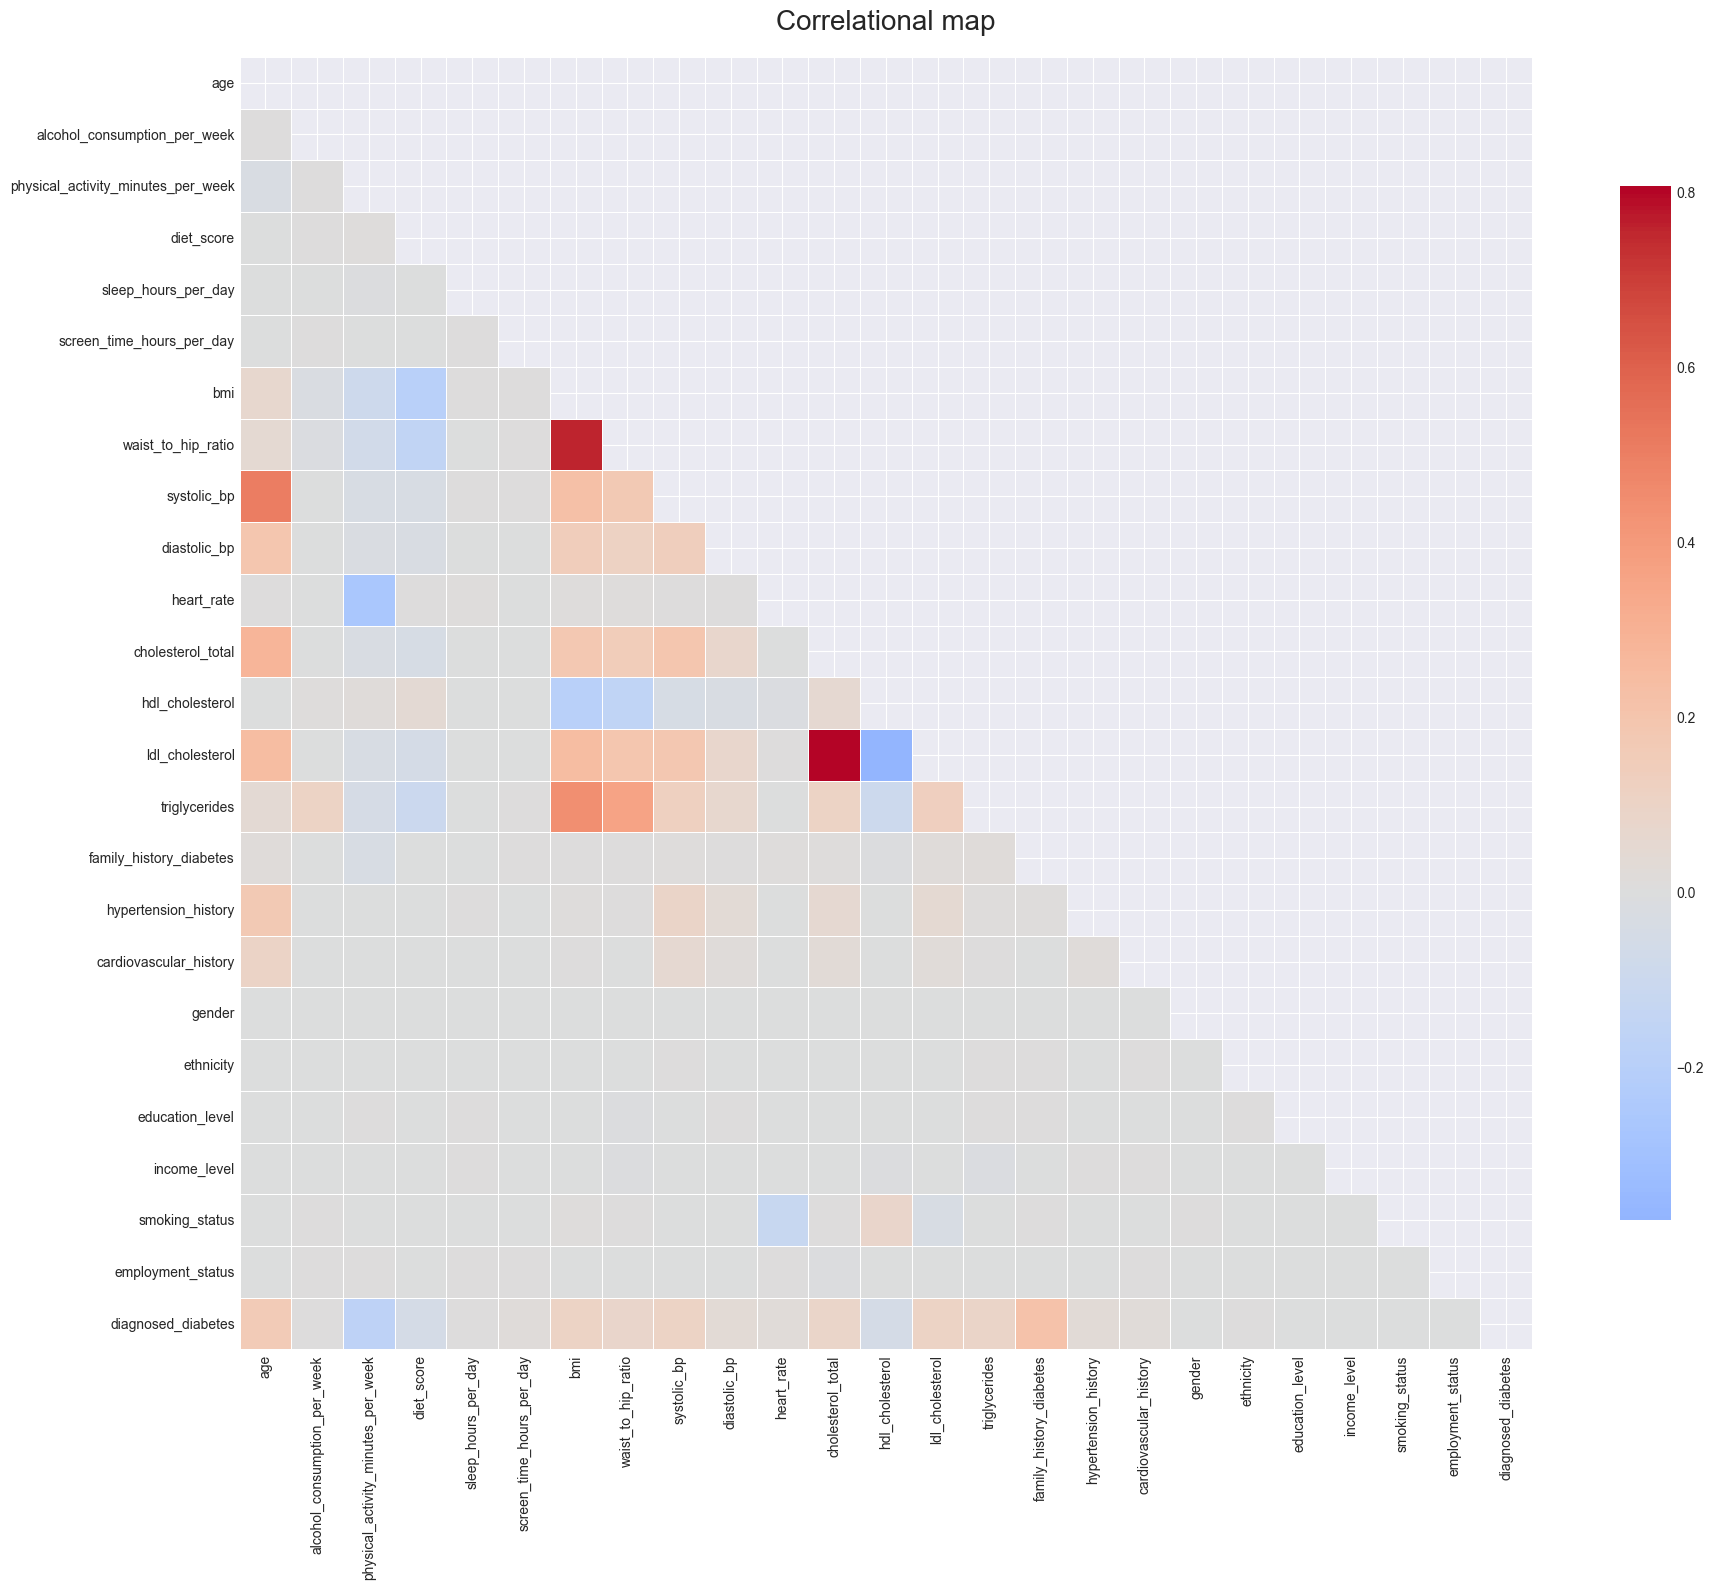

In [7]:
target_corr = corr_matrix['diagnosed_diabetes'].sort_values(ascending=False)
print("Top 10 features by correlation with the target variable:")
print(target_corr.abs().sort_values(ascending=False).head(11))
plt.figure(figsize=(20, 16))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            cmap = 'coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink":0.8},
            annot = False)

plt.title('Correlational map', fontsize=20, pad=20)
plt.tight_layout()
plt.show()

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_feature),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_feature)
    ]
)

In [9]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
X_train.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history
count,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000,560000.00000,560000.000000,560000.000000,560000.000000,560000.000000,560000.000000
mean,50.360098,2.071616,80.213493,5.963169,7.001611,6.011431,25.873794,0.858766,116.295496,75.440743,70.171162,186.826730,53.81910,102.923093,123.085934,0.149280,0.182143,0.030366
std,11.653191,1.047199,51.172618,1.463713,0.901866,2.023708,2.859788,0.037979,11.008420,6.823348,6.936900,16.731938,8.27154,19.025241,24.746970,0.356365,0.385963,0.171593
min,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.00000,51.000000,31.000000,0.000000,0.000000,0.000000
25%,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.00000,89.000000,106.000000,0.000000,0.000000,0.000000
50%,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.00000,103.000000,123.000000,0.000000,0.000000,0.000000
75%,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.00000,116.000000,139.000000,0.000000,0.000000,0.000000
max,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.00000,205.000000,290.000000,1.000000,1.000000,1.000000


In [12]:
model.fit(X_train, y_train)

KeyboardInterrupt: 